In [3]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import cupy as cp
import sys #首先，添加路径，windows的路径和linux的路径符号不同\\,/,注意区别  #r是为了告诉python这是路径，别#把\n等特殊组合给转译）
sys.path.append(r"./main_code")
import generate_data2,grid_cell,adaptive_int,visual,cal_S_grad,org_m,mea_2D,net_2D_fix2,S_valgrad,error_general_2D,main,org_matrix_2D,choose_lambda
CUDA_LAUNCH_BLOCKING=1



cuda:0


In [ ]:
import numpy as np
M=3200
w=np.random.randn(M, 1)
tau_x_min,tau_x_max,tau_y_min,tau_y_max=0,2,0,2
b_x_min,b_x_max,b_y_min,b_y_max=-0.5,2.5,-0.5,2.5 #边界gamma处
b_n=15
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77,81,85,89]
points_b=mea_2D.p_b(b_x_min,b_x_max,b_y_min,b_y_max,b_n) #在边界Γ处收集数据
Nx,Ny=1,1
R_m=20
af="sin"
#model=net_2D_fix2.pre_define(Nx,Ny,M,R_m,af,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],device)
model =torch.load("./results/model_3200.pth")
num_batches_gauss=10 #高斯点的批次数
batch_number_mea=1 #测量点的批次数
grad_temp=0
number_appr=100 #逼近时用的高斯点
cupy_device=0
S_basis,b_matrix,db_x1_matrix,db_x2_matrix,grads_y1,grads_y2=org_matrix_2D.residual_vector(model,points_b,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],M,af,"rec",1,kk,number_appr,num_batches_gauss,batch_number_mea,grad_temp,device,cupy_device)
all_mat=org_m.A(b_matrix,db_x1_matrix,db_x2_matrix)

/tmp/ipykernel_2845540/1475522447.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model =torch.load("./results/model_3200.pth")


In [38]:
# A_gpu = cp.asarray(S_basis)
# U, s, Vt = cp.linalg.svd(A_gpu, full_matrices=False)
# cond_S_basis = (s[0] / s[-1]).item()  # 最大奇异值 / 最小奇异值
print("正在计算 all_mat 的谱范数以进行归一化...")
largest_singular_value = cp.linalg.norm(cp.asarray(all_mat), 2)
print(f"all_mat 的最大奇异值为: {largest_singular_value}")

# 2. 创建归一化的矩阵
all_mat_normalized = all_mat / largest_singular_value.get()

正在计算 all_mat 的谱范数以进行归一化...
all_mat 的最大奇异值为: 84.70535657579728


In [40]:
np.random.seed(3)
eps=0.05
perturbation = np.random.uniform(-eps, eps, size=all_mat.shape[0]).reshape(-1,1)

In [41]:
perturbation

array([[ 0.00507979],
       [ 0.02081478],
       [-0.02090953],
       ...,
       [ 0.01819563],
       [ 0.03886722],
       [-0.01851552]])

In [ ]:
w=np.load("./results/w.npy")

In [46]:
import choose_lambda
eta_foundation=0.01
eta_M=np.logspace(-2,2,5)*eta_foundation
iter=eta_M.shape[0]
nu=1
eps=0.05
delta_store=[]
lambda_store=[]
error_s_store=[]
error_S_store=[]
bound_store=[]
S_delta_store=[]
S_star_store=[]
s_delta_store=[]
s_star_store=[]
U_true_store=[]
for i in range(len(eta_M)):
    s_star,U_true=choose_lambda.Inconsistency(all_mat_normalized,eta_M[i],nu,w)
    U_true_store.append(U_true)
    delta,lambda_reg2,s_delta,s_star,S_delta,S_star,error_s,error_S,bound=choose_lambda.prior(M,w,all_mat_normalized,S_basis,perturbation,eta_M[i],nu,s_star,U_true)
    s_star_store.append(s_star)
    s_delta_store.append(s_delta)
    S_star_store.append(S_star)
    S_delta_store.append(S_delta)
    delta_store.append(delta)
    lambda_store.append(lambda_reg2)
    error_s_store.append(error_s)
    error_S_store.append(error_S)
    bound_store.append(bound)

In [47]:
delta_store

[np.float64(0.01134842657861784),
 np.float64(0.011348552817772284),
 np.float64(0.011353139575925817),
 np.float64(0.011725294015010814),
 np.float64(0.03127486071802887)]

In [48]:
lambda_store

[np.float64(0.0013578098191004873),
 np.float64(0.0014280797202945806),
 np.float64(0.0020573881561462607),
 np.float64(0.006200728940550389),
 np.float64(0.027285046414504053)]

In [49]:
error_S_store

[np.float64(3.35088019453594),
 np.float64(3.3141292803149107),
 np.float64(3.108987828397059),
 np.float64(4.607027407752681),
 np.float64(16.907311705081923)]

In [50]:
error_s_store

[np.float64(0.007634463721674277),
 np.float64(0.007432801291124919),
 np.float64(0.005993779222939193),
 np.float64(0.003790676470744437),
 np.float64(0.013372720425207003)]

In [51]:
bound_store

[np.float64(0.23301699332702291),
 np.float64(0.24507617928023834),
 np.float64(0.35307330637027146),
 np.float64(1.0641219365463856),
 np.float64(4.682452129052894)]

In [52]:
g=generate_data2.GaussLegendre2D_rec(number_appr,tau_x_min,tau_x_max,tau_y_min,tau_y_max,points_b)
gauss_points=g.points_int

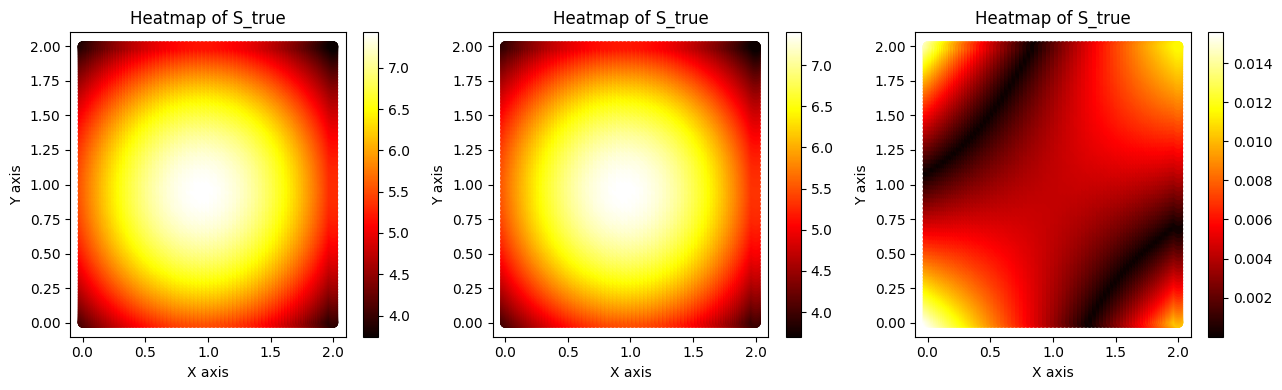

In [55]:
import matplotlib.pyplot as plt
S_2d = S_star_store[1]
#S_2d =(S_basis@s_star_store[-1]).reshape(100,100)
S_delta = S_delta_store[1]

plt.figure(figsize=(13, 4))

# 第一个热力图：S_true
plt.subplot(1, 3, 1)
plt.scatter(gauss_points[:, 0], gauss_points[:, 1], c=S_2d, cmap='hot')
plt.colorbar()
plt.title("Heatmap of S_true")
plt.xlabel("X axis")
plt.ylabel("Y axis")

# 第二个热力图：S_delta
plt.subplot(1, 3, 2)
plt.scatter(gauss_points[:, 0], gauss_points[:, 1], c=S_delta, cmap='hot')
plt.colorbar()
plt.title("Heatmap of S_true")
plt.xlabel("X axis")
plt.ylabel("Y axis")

plt.subplot(1, 3, 3)
plt.scatter(gauss_points[:, 0], gauss_points[:, 1], c=np.abs((S_2d-S_delta)/S_2d), cmap='hot')
plt.colorbar()
plt.title("Heatmap of S_true")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.tight_layout()
plt.show()


S_l_inf= 0.010510223655224752 S_L_2= 0.02935072418337025 S_l_2= 0.004796580651909409


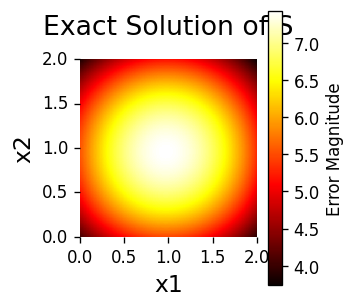

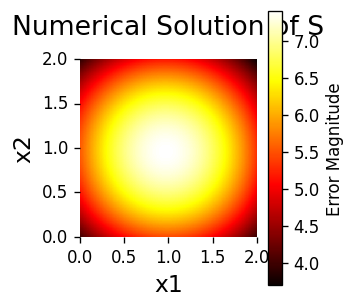

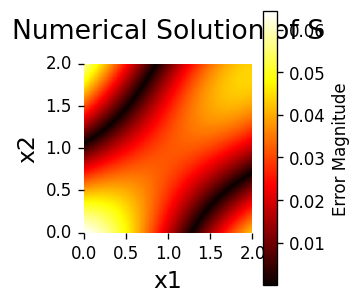

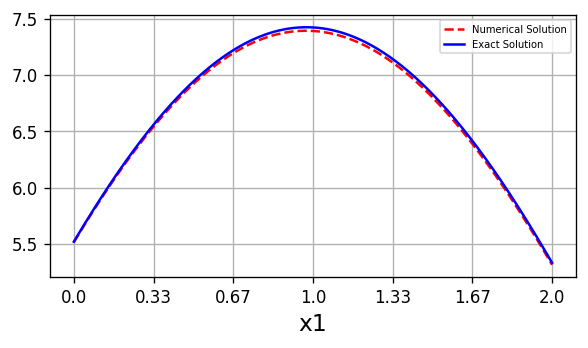

S_l_inf= 0.010383758923951224 S_L_2= 0.029295536535303934 S_l_2= 0.004787561726063305


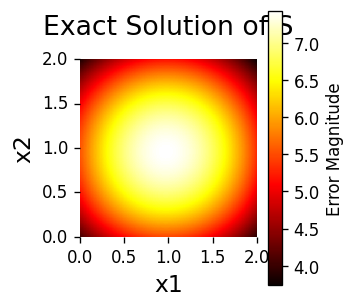

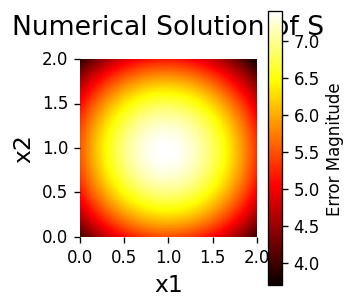

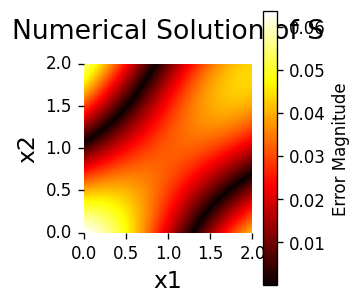

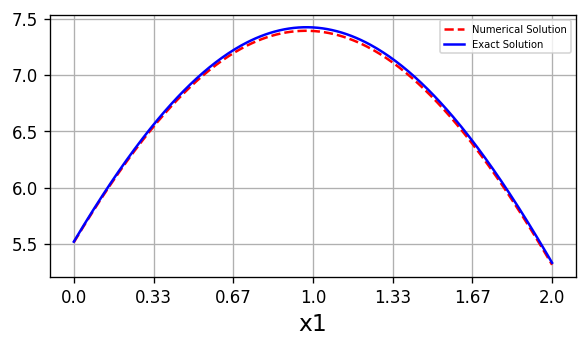

S_l_inf= 0.009474883524534988 S_L_2= 0.029774616775254965 S_l_2= 0.0048658544112899


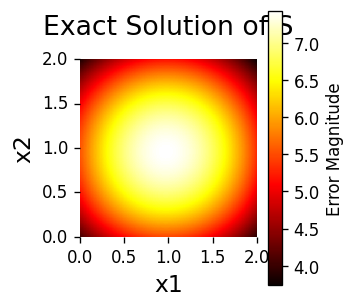

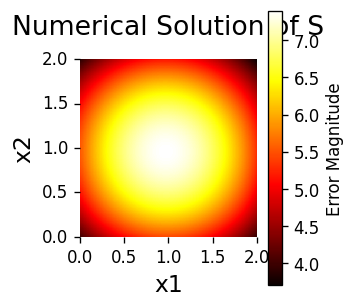

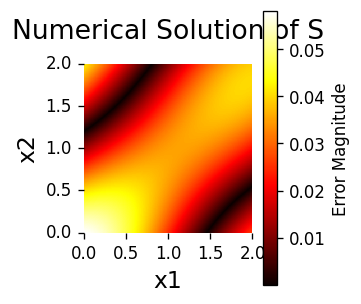

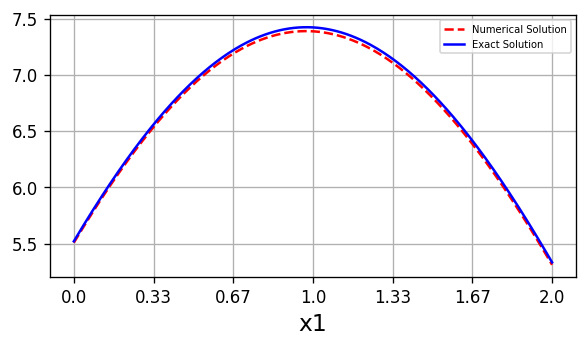

S_l_inf= 0.011118623768408577 S_L_2= 0.05095704205169879 S_l_2= 0.008327547915229895


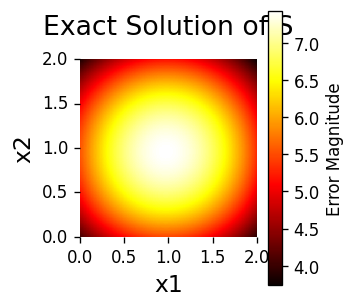

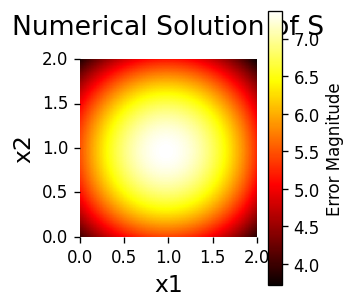

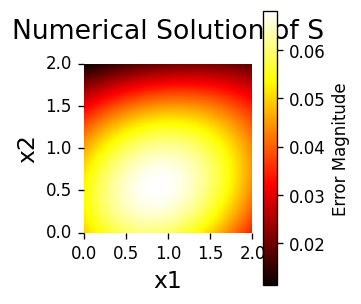

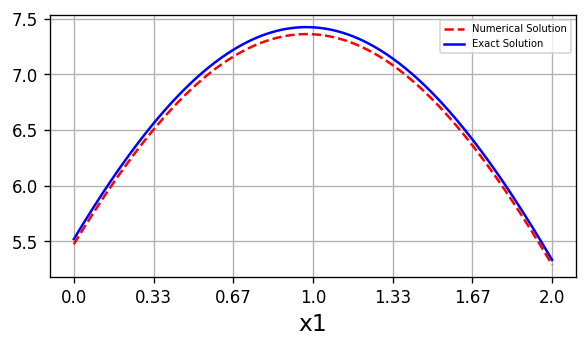

S_l_inf= 0.038613522382361785 S_L_2= 0.18433300826644938 S_l_2= 0.030124235962125486


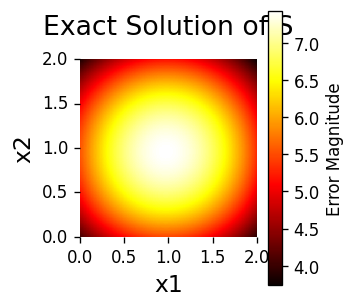

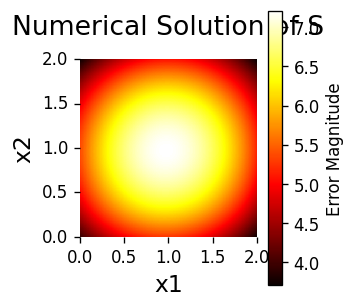

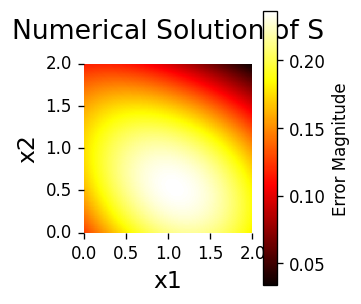

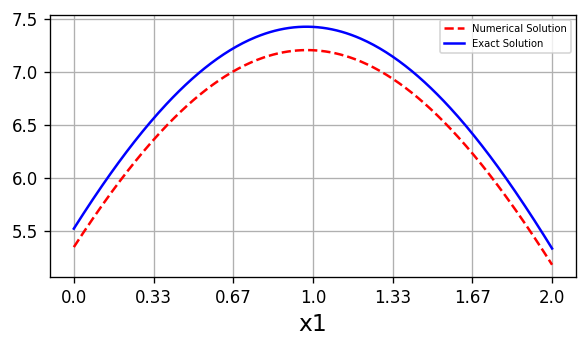

In [56]:
import test_error
Qx=150
Qy=150
af="sin"
S_num_test_store=[]
S_star_test_store=[]
error_S_test=[]
for i in range(iter):
    S_num,S_star_test,S_l_inf,S_l_2=test_error.test(model,M,Qx,Qy,s_delta_store[i],s_star,af,True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,device)
    S_num_test_store.append(S_num)
    S_star_test_store.append(S_star_test)
    error_S_test.append(S_l_2)

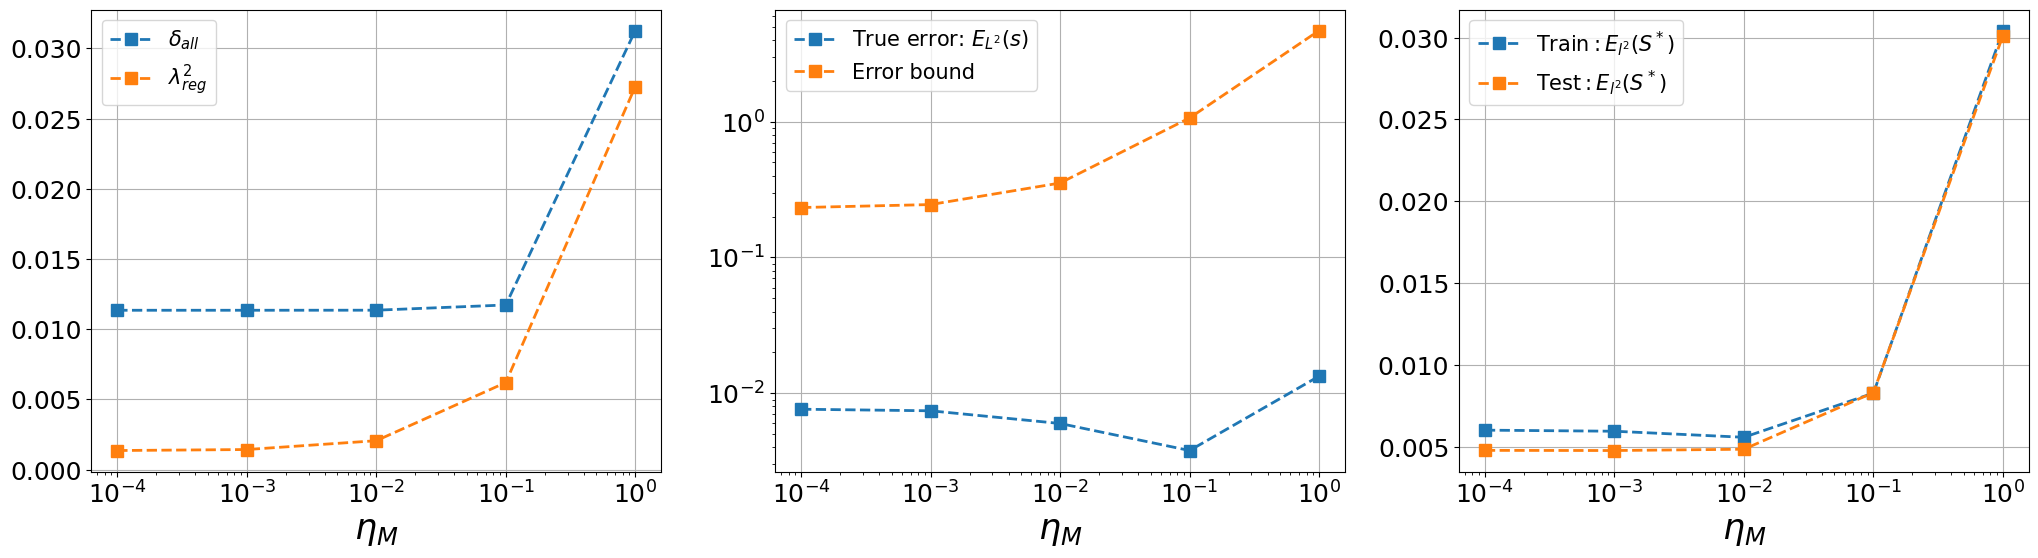

In [ ]:
_, axes = plt.subplots(nrows=1, ncols=3, figsize=(25, 6))
axes = axes.reshape(-1)
grid = eta_M
axes[0].plot(eta_M, delta_store, label='$\delta_{all}$', marker='s', markersize=8, linestyle='--', linewidth=2)
axes[0].plot(eta_M, lambda_store, label='$\lambda_{reg}^2$', marker='s', markersize=8, linestyle='--', linewidth=2)
axes[0].set_xlabel(r"$\eta_M$", fontsize=25)
axes[0].tick_params(axis='both', labelsize=18)
axes[0].legend(fontsize=15)
axes[0].legend(fontsize=15)

axes[0].set_xscale('log')
axes[0].grid(True)  # 添加网格线

#plt.yscale('log') 

axes[1].plot(eta_M, error_s_store, label='True error: $ E_{L^2}(s)$', marker='s', markersize=8, linestyle='--', linewidth=2)
axes[1].plot(eta_M, bound_store, label='Error bound', marker='s', markersize=8, linestyle='--', linewidth=2)

axes[1].legend(fontsize=15)

axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel(r"$\eta_M$", fontsize=25)
axes[1].tick_params(axis='both', labelsize=18)
axes[1].legend(fontsize=15)
axes[1].grid(True)  

axes[2].plot(eta_M, np.array(error_S_store)/np.linalg.norm(np.array(S_star_store[-1])), label='Train$:E_{l^2}(S^*)$', marker='s', markersize=8, linestyle='--', linewidth=2)
axes[2].plot(eta_M, error_S_test, label='Test$:E_{l^2}(S^*)$', marker='s', markersize=8, linestyle='--', linewidth=2)
axes[2].set_xlabel(r"$\eta_M$", fontsize=25)
axes[2].tick_params(axis='both', labelsize=18)
axes[2].legend(fontsize=15)
axes[2].set_xscale('log')
axes[2].grid(True)  
plt.savefig("./results/theorem.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [58]:
np.save('./results/w.npy',w)
torch.save(model,"./results/model_3200.pth")
np.save("./results/S_basis.npy",S_basis)
np.save("./results/all_mat.npy",all_mat)
np.save("./results/all_mat_normalized.npy",all_mat_normalized)
np.save("./results/lambda_store.npy",lambda_store)
np.save("./results/error_s_store.npy",error_s_store)
np.save("./results/error_S_store.npy",error_S_store)
np.save("./results/bound_store.npy",bound_store)
np.save("./results/S_delta_store.npy",S_delta_store)
np.save("./results/S_star_store.npy",S_star_store)
np.save("./results/S_num_test_store.npy",S_num_test_store)
np.save("./results/S_star_test_store.npy",S_star_test_store)